<a href="https://colab.research.google.com/github/A-ghori/sklearn/blob/recovery/Assumption_Of_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import  LinearRegression
from sklearn.model_selection import  train_test_split


In [14]:
df = pd.read_csv("/content/data (1).csv")
df.head(2)

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355


In [15]:
X = df.iloc[:,0:3]
y = df.iloc[:,-1]
y

,target
0,-9.763182
1,-24.029355
2,45.616421
3,34.135737
4,86.663647
...,...
195,38.067836
196,12.812755
197,70.454115
198,-93.235783


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
# Residual
y_pred = model.predict(X_test)
Residual = y_test - y_pred
Residual

,target
95,-12.946858
15,-17.217711
30,1.766695
158,-26.558474
128,24.478078
115,0.361432
69,-18.989699
170,-29.273016
174,-4.818961
45,-4.710372


## Step1 -> Linear Relationship between input and output

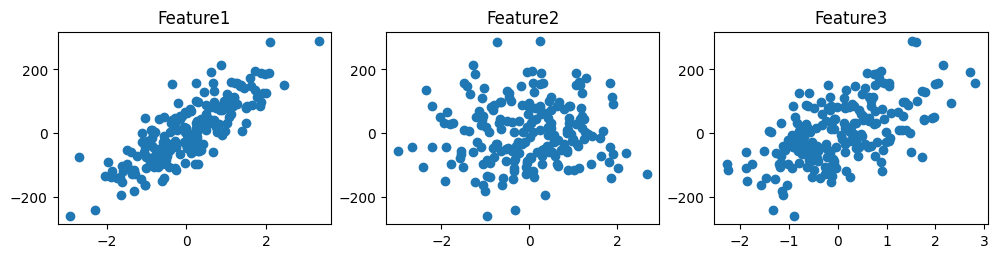

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12,2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

## Checking Multicollinearity

VIF	Interpretation
1	 No multicollinearity
1–5	 Generally okay
5–10	 High — investigate
>10	  Very high — serious multicollinearity

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
  vif.append(variance_inflation_factor(X_train, i))

pd.DataFrame(vif, index=X_train.columns, columns=['VIF'])

,VIF
feature1,1.001999
feature2,1.011300
feature3,1.011173


## Normal Residuals

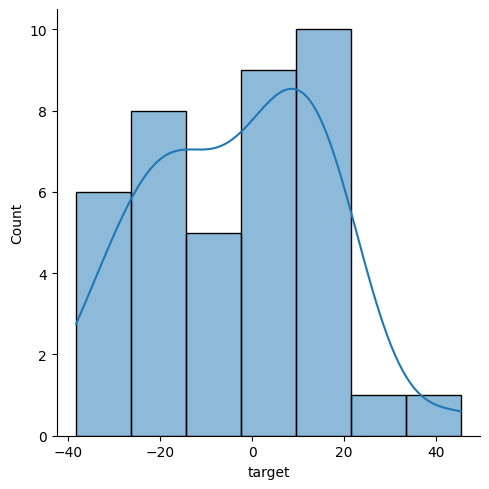

In [21]:
## Distribution Plots
sns.displot(Residual, kde=True)


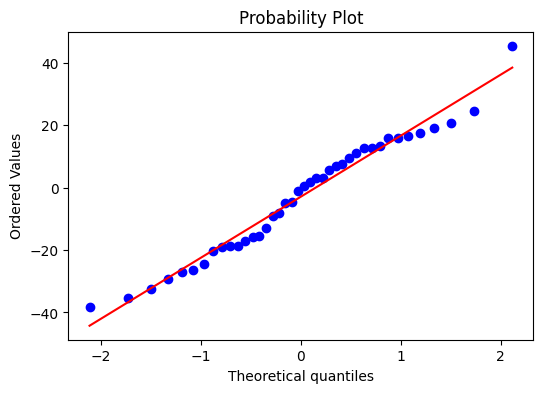

In [22]:
## QQ PLOT
import scipy as sp
fig , ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(Residual, plot=ax)

plt.show()


## Homoscedasicity

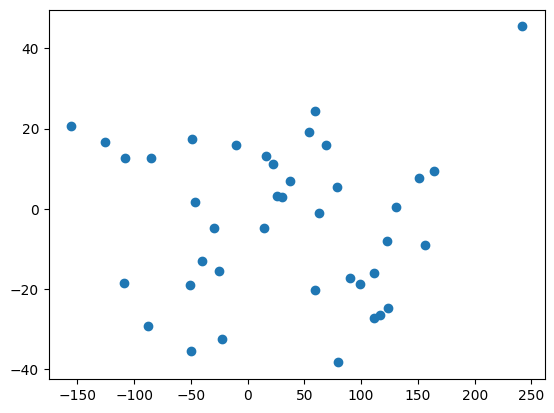

In [23]:
plt.scatter(y_pred, Residual)
plt.show()

## Negative AutoCorrelation

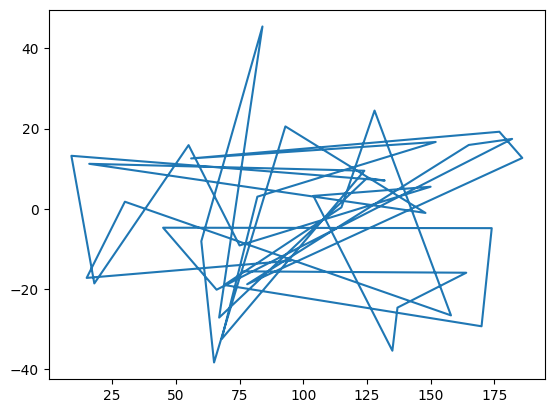

In [24]:
plt.plot(Residual)